<a href="https://colab.research.google.com/github/Vlasovasona/ML-home-works/blob/main/%D0%91%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [ ]:
import pandas as pd

df = pd.read_csv("https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw08_boosting_clustering/ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from sklearn.model_selection import train_test_split
y = df["salary_in_usd"]
X = df.drop(columns=["salary_in_usd", "salary"])

categorical_features = X.select_dtypes(include=['object']).columns.tolist() # для удобства кодирую категориальные переменные здесь

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data_train = encoder.fit_transform(X[categorical_features])
X = pd.DataFrame(encoded_data_train, columns=encoder.get_feature_names_out(categorical_features))

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [ ]:
X_val.head()

,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_FL,employment_type_FT,employment_type_PT,job_title_AI Developer,job_title_AI Programmer,job_title_AI Scientist,job_title_Analytics Engineer,...,company_location_SG,company_location_SI,company_location_SK,company_location_TH,company_location_TR,company_location_UA,company_location_US,company_location_VN,company_size_M,company_size_S
3684,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2082,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2067,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2536,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2628,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


Лик в данных возможен из-за признака salary. Для многих объектов значения salary и целевой переменной одинаковые, что может привести к лику в данных. Эту переменную исключаем из датасета.



---



## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


In [ ]:
X_test.head()

,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_FL,employment_type_FT,employment_type_PT,job_title_AI Developer,job_title_AI Programmer,job_title_AI Scientist,job_title_Analytics Engineer,...,company_location_SG,company_location_SI,company_location_SK,company_location_TH,company_location_TR,company_location_UA,company_location_US,company_location_VN,company_size_M,company_size_S
2148,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1044,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3321,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
439,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3519,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

mape_score = mean_absolute_percentage_error(y_val, y_pred)
mse_score = mean_squared_error(y_val, y_pred)

rmse_score = mse_score ** 0.5

print(f'MAPE: {mape_score:.4f}')
print(f'RMSE: {rmse_score:.4f}')

MAPE: 0.3765
RMSE: 53449.3301


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [ ]:
from xgboost.sklearn import XGBRegressor
from sklearn.model_selection import GridSearchCV
import time

In [ ]:
params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300],
    'gamma': [0, 0.1, 0.5]
}

xgb_model = XGBRegressor()

In [ ]:
grid_search = GridSearchCV(xgb_model, params, cv=3, scoring='neg_mean_squared_error', verbose=1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Лучшие параметры:", best_params)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Лучшие параметры: {'gamma': 0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}


In [ ]:
final_xgb_model = XGBRegressor(**best_params)
start_time_fit = time.time()
final_xgb_model.fit(X_train, y_train)
end_time_fit = time.time()

training_time = end_time_fit - start_time_fit
print(f"Скорость обучения: {training_time:.2f}")

Скорость обучения: 0.68


In [ ]:
start_time_predict = time.time()
y_pred = final_xgb_model.predict(X_val)
end_time_predict = time.time()
prediction_time = end_time_predict - start_time_predict
print(f"Скорость прогнозирования: {prediction_time:.2f}")

Скорость прогнозирования: 0.06


In [ ]:
mape_score = mean_absolute_percentage_error(y_val, y_pred)
rmse_score = (mean_squared_error(y_val, y_pred))**0.5

print(f"MAPE: {mape_score:.2f}")
print(f"RMSE: {rmse_score:.2f}")

MAPE: 0.34
RMSE: 50800.54


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

params = {
    'depth' : [1, 2, 3] ,
    'learning_rate' : [0.3, 0.4, 0.5],
    'iterations' : [300, 350, 400] ,
}

cbt_model = CatBoostRegressor()

In [ ]:
grid_search = GridSearchCV(cbt_model, params, cv=3, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Лучшие параметры:", best_params)

Выходные данные были обрезаны до нескольких последних строк (5000).
301:	learn: 42776.3510004	total: 147ms	remaining: 23.4ms
302:	learn: 42776.0952788	total: 148ms	remaining: 22.9ms
303:	learn: 42765.3215002	total: 148ms	remaining: 22.4ms
304:	learn: 42764.4449137	total: 149ms	remaining: 21.9ms
305:	learn: 42764.3619820	total: 149ms	remaining: 21.4ms
306:	learn: 42762.0214943	total: 150ms	remaining: 21ms
307:	learn: 42758.4358157	total: 150ms	remaining: 20.5ms
308:	learn: 42756.7230815	total: 151ms	remaining: 20ms
309:	learn: 42749.5087374	total: 151ms	remaining: 19.5ms
310:	learn: 42745.3332757	total: 152ms	remaining: 19ms
311:	learn: 42743.1747072	total: 152ms	remaining: 18.5ms
312:	learn: 42736.6915637	total: 152ms	remaining: 18ms
313:	learn: 42735.2268516	total: 153ms	remaining: 17.5ms
314:	learn: 42733.4787089	total: 153ms	remaining: 17ms
315:	learn: 42693.5400535	total: 154ms	remaining: 16.6ms
316:	learn: 42687.0814780	total: 154ms	remaining: 16.1ms
317:	learn: 42686.8876923	tota

In [ ]:
final_cbt_model = CatBoostRegressor(**best_params, verbose=False)
start_time_fit = time.time()
final_cbt_model.fit(X_train, y_train)
end_time_fit = time.time()

training_time = end_time_fit - start_time_fit
print(f"Скорость обучения: {training_time:.2f}")

Скорость обучения: 0.30


In [ ]:
start_time_predict = time.time()
y_pred = final_cbt_model.predict(X_val)
end_time_predict = time.time()
prediction_time = end_time_predict - start_time_predict
print(f"Скорость прогнозирования: {prediction_time:.2f}")

Скорость прогнозирования: 0.01


In [ ]:
mape_score = mean_absolute_percentage_error(y_val, y_pred)
rmse_score = (mean_squared_error(y_val, y_pred))**0.5

print(f"MAPE: {mape_score:.2f}")
print(f"RMSE: {rmse_score:.2f}")

MAPE: 0.35
RMSE: 50559.46


Здесь ниде скорость обучения, но при этом метрики немного хуже.

Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [ ]:
df = pd.read_csv("https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw08_boosting_clustering/ds_salaries.csv")

y = df["salary_in_usd"]
X = df.drop(columns=["salary_in_usd", "salary"])

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [ ]:
from catboost import Pool
categorical_indices = X.select_dtypes(include=['object']).columns.tolist()

train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_indices)
valid_pool = Pool(data=X_val, label=y_val, cat_features=categorical_indices)

In [ ]:
model = CatBoostRegressor(**best_params, verbose=False)

start_time_fit = time.time()
model.fit(train_pool)
end_time_fit = time.time()

training_time = end_time_fit - start_time_fit
print(f"Скорость обучения: {training_time:.2f}")

Скорость обучения: 1.06


In [ ]:
start_time_predict = time.time()

predictions = model.predict(valid_pool)

end_time_predict = time.time()

prediction_time = end_time_predict - start_time_predict
print(f"Скорость прогнозирования: {prediction_time:.5f}")

Скорость прогнозирования: 0.00398


In [ ]:
mape_score = mean_absolute_percentage_error(y_val, y_pred)
rmse_score = (mean_squared_error(y_val, y_pred))**0.5

print(f"MAPE: {mape_score:.2f}")
print(f"RMSE: {rmse_score:.2f}")

MAPE: 0.35
RMSE: 50559.46


**Ответ:** качество осталось неизменным (что логично, так как оба способа используют одинаковые модели с одинаковыми гиперпараметрами, различается только способ кодирования качественные признаков). Время обучения во втором случае увеличилось, так как вторая модель самостоятельно кодирует признаки, на что требудется дополнительное время. При этом время прогнозирования во втором случае немного уменьшилось.

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [ ]:
y = df["salary_in_usd"]
X = df.drop(columns=["salary_in_usd", "salary"])

categorical_features = X.select_dtypes(include=['object']).columns.tolist() # для удобства кодирую категориальные переменные здесь

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data_train = encoder.fit_transform(X[categorical_features])
X = pd.DataFrame(encoded_data_train, columns=encoder.get_feature_names_out(categorical_features))

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [ ]:
from lightgbm import LGBMRegressor


params = {
    'max_depth' : [1, 3, 5],
    'learning_rate' : [0.01, 0.05, 0.1],
    'n_estimators' : [50, 100, 300]
}


lgbmr_model = LGBMRegressor()

In [ ]:
grid_search = GridSearchCV(lgbmr_model, params, cv=3, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Лучшие параметры:", best_params)

Выходные данные были обрезаны до нескольких последних строк (5000).
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [ ]:
lgbmr_model = LGBMRegressor(**best_params)

start_time_fit = time.time()
lgbmr_model.fit(X_train, y_train)
end_time_fit = time.time()

training_time = end_time_fit - start_time_fit
print(f"Скорость обучения: {training_time:.2f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 70
[LightGBM] [Info] Number of data points in the train set: 2403, number of used features: 35
[LightGBM] [Info] Start training from score 137515.985851
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [ ]:
start_time_predict = time.time()
y_pred = lgbmr_model.predict(X_val)
end_time_predict = time.time()
prediction_time = end_time_predict - start_time_predict
print(f"Скорость прогнозирования: {prediction_time:.2f}")

Скорость прогнозирования: 0.01


In [ ]:
mape_score = mean_absolute_percentage_error(y_val, y_pred)
rmse_score = (mean_squared_error(y_val, y_pred))**0.5

print(f"MAPE: {mape_score:.2f}")
print(f"RMSE: {rmse_score:.2f}")

MAPE: 0.37
RMSE: 51100.77


## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ**

**Лучшая по качеству:** XGBRegressor.

**Худшая по качеству:** LinearRegression.

**Лучшая по скорости:** LGBMRegressor

**Худшая по скорости:** CatBoostRegressor


**XGBRegressor**

max_depth: 3 - максимальная глубина деревьев в ансамбле.

learning_rate: 0.2 - снижает вклад каждого дерева в общую модель.

n_estimators: 200 - количество базовых моделей в ансамбле (чем меньше вклад модели learning_rate, тем больше нужно деревьев в ансамбле).

gamma: 0 - параметр регуляризации

**LGBMRegressor**

Быстрее всех благодаря своему принципу выбора того листа, чье разбиение сильнее всего уменьшает ошибку. Соответственно, процесс обучения проходит быстрее всего.

**CatBoostRegressor**

iterations аналогично n_estimators. Самый долгий из-за обработки категориальных признаков.

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [ ]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [ ]:
import numpy as np

In [ ]:
ratings = ratings.drop(columns='user')

In [ ]:
column_names = ratings.columns
array_ratings = np.array(ratings).T
transposed_df = pd.DataFrame(array_ratings, index=column_names)

Выкиньте строку под названием `user`.

In [ ]:
# сделала выше

В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [ ]:
ratings = pd.DataFrame(transposed_df)
transposed_df.fillna(0, inplace=True)
transposed_df.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
crystal castles,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019394


In [ ]:
transposed_df.reset_index(inplace=True)
transposed_df.rename(columns={'index': 'group'}, inplace=True)

In [ ]:
transposed_df.head()

,group,0,1,2,3,4,5,6,7,8,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,the beatles,0.000000,0.000000,0.000000,0.0,0.043529,0.000000,0.0,0.0,0.093398,...,0.000000,0.0,0.121169,0.038168,0.007939,0.017884,0.0,0.076923,0.0,0.000000
1,radiohead,0.020417,0.184962,0.000000,0.0,0.086281,0.006322,0.0,0.0,0.000000,...,0.017735,0.0,0.000000,0.000000,0.011187,0.000000,0.0,0.000000,0.0,0.000000
2,deathcab for cutie,0.000000,0.024561,0.028635,0.0,0.034590,0.000000,0.0,0.0,0.000000,...,0.121344,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.027893
3,coldplay,0.000000,0.000000,0.000000,0.0,0.016712,0.000000,0.0,0.0,0.000000,...,0.217175,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
4,modest mouse,0.000000,0.000000,0.000000,0.0,0.015935,0.000000,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [ ]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=5)
model.fit(transposed_df.iloc[:, 1:])

KMeans(n_clusters=5)

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [ ]:
labels = model.labels_
cluster_sizes = {x: int(sum(labels == x)) for x in range(0, model.n_clusters)}
print(cluster_sizes)

{0: 996, 1: 1, 2: 1, 3: 1, 4: 1}


**Ответ:** кластеризация получилась бесполезной. Могу предположить, что для данной выборки количество кластеров слишком мало, поэтому выбросы заполнили первые 4 кластера, а все остальные значения ушли в пятый кластер.

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [ ]:
labels = model.labels_
single_element_clusters = [x for x, y in cluster_sizes.items() if y == 1]
single_element_clusters

[1, 2, 3, 4]

In [ ]:
result_records = transposed_df.loc[[index for index, label in enumerate(labels) if label in single_element_clusters]]
result_records

,group,0,1,2,3,4,5,6,7,8,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,the beatles,0.000000,0.0,0.000000,0.0,0.043529,0.000000,0.000000,0.000000,0.093398,...,0.0,0.0,0.121169,0.038168,0.007939,0.017884,0.0,0.076923,0.0,0.0
17,daft punk,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.026428,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
24,bright eyes,0.000000,0.0,0.014369,0.0,0.046638,0.030833,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
96,eminem,0.029333,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.014324,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [ ]:
filtered_columns = transposed_df.columns[1:]
columns = filtered_columns[(transposed_df[filtered_columns] > 0).all()]
prop = len(columns) / len(filtered_columns)

print(f"Доля пользователей, которые слушают каждого исполнителя: {prop:.2f}")

Доля пользователей, которые слушают каждого исполнителя: 0.00


In [ ]:
beatles_row = transposed_df[transposed_df["group"] == "the beatles"]
beatles_series = beatles_row.squeeze()
beatles_df = pd.DataFrame({ 'Beatles': beatles_series })

In [ ]:
beatles_df = beatles_df.drop(index="group")

In [ ]:
mean_value = beatles_df["Beatles"].mean()
std_deviation = beatles_df["Beatles"].std()

print(f"{mean_value}")
print(f"{std_deviation}")

0.01836897659205149
0.04765611353954916


In [ ]:
print("Доля пользователей, слушающих битлз:")
print((beatles_df["Beatles"] > 0).sum() / beatles_df.shape[0])

Доля пользователей, слушающих битлз:
0.3342


In [ ]:
mean = 0
std = 0
count = 0

In [ ]:
for _, row in (transposed_df).iloc[: , 1:].iterrows():
    mean_value = row.mean()
    std_deviation = row.std()

    mean += mean_value
    std += std_deviation
    count += (row > 0).sum()

average_mean = mean / len(transposed_df.index[1:])
average_std = std / len(transposed_df.index[1:])
average_count = count / len(transposed_df.index[1:])

print(f"Среднее mean по выборке: {average_mean:.4f}")
print(f"Среднее std по выборке: {average_std:.4f}")
print(f"Средняя доля пользователей, которые слушают группу: {average_std:.2f}")

Среднее mean по выборке: 0.0030
Среднее std по выборке: 0.0260
Средняя доля пользователей, которые слушают группу: 0.03


**Ответ:** доля пользователей, слушающих битлз гораздо больше среднего по общей выборке. Это говорит о том, что эта группа находится сильно далеко от остальных и поэтому для нее выделяется отдельный кластер.

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [ ]:
from sklearn.preprocessing import normalize

norm = normalize((transposed_df).iloc[: , 1:])

In [ ]:
norm_df = pd.DataFrame(norm)
norm_df.insert(0, "group", transposed_df["group"])

In [ ]:
norm_df.head()

,group,0,1,2,3,4,5,6,7,8,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,...,0.000000,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000
1,radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,...,0.008120,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000
2,deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,...,0.085361,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622
3,coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,...,0.144628,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
4,modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [ ]:
model = KMeans(n_clusters=5)
model.fit(norm_df.iloc[:, 1:])
labels = model.labels_
cluster_sizes = {x: int(sum(labels == x)) for x in range(0, model.n_clusters)}
print(cluster_sizes)

{0: 291, 1: 119, 2: 361, 3: 161, 4: 68}


**Ответ** однозначно модель стала лучше описывать данные, все кластеры стали содержать более 70 объектов, выборка более менее равномерно распределилась между кластерами. Это обуслевлено масштабированием признаков, так как масштабирование позволяет уменьшить влияние выбросов на формирование итогового списка кластеров.

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [ ]:
from scipy.spatial.distance import cosine

norm = pd.DataFrame(norm)
centroids = model.cluster_centers_

groups = norm_df["group"]

top = 10
results = {}

for label in range(len(centroids)):
    cluster_indices = labels == label
    current_cluster_points = norm[cluster_indices]
    distances = [cosine(x, centroids[label]) for x in current_cluster_points.values]
    top_indices = sorted(range(len(distances)), key=lambda i: distances[i])[:top]
    closest_artists = groups.iloc[current_cluster_points.index[top_indices]].values.tolist()
    results[f"Cluster_{label}"] = closest_artists

for i, m in results.items():
    print(f"{i}: {m}\n")

Cluster_0: ['radiohead', 'the arcade fire', 'broken social scene', 'sufjan stevens', 'belle and sebastian', 'animal collective', 'the shins', 'of montreal', 'deathcab for cutie', 'beirut']

Cluster_1: ['kanye west', 'jay-z', 'chiodos', 'underoath', 'saosin', 'nas', "lil' wayne", 'a day to remember', 'brand new', 'blink-182']

Cluster_2: ['the beatles', 'led zeppelin.', 'pink fluid', 'the rolling stones', 'metallica', 'acdc', 'system of a down', 'tool', 'red hot clili peppers', 'niИ']

Cluster_3: ['kelly clarkson', 'john mayer', 'maroon5', 'the all-americian rejects', 'the fray', 'fall out boy', 'dashboard confesssional', 'coldplay', 'paramore', 'the killers']

Cluster_4: ['a tribe called quest', 'mos def', "the roots featuring d'angelo", 'alicia keys', 'laurуn hill', 'talib kweli', 'mary j. blige', 'de la soul', 'little brother', 'scott jill']



**Ответ:** топ-10 групп каждого кластера похожи по стилю или эпохе. Например в одном кластере оказались Beatles, Rolling Stones, Metallica, Ac/Dc и Red hot cili peppers. Эти музыкальные группы уверенно можно поместить в одну категорию.

Можно сказать, что кластеризация прошла по жанрам и настроению музыки, выпускаемой исполнителями, объединенными в один кластер.

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

In [ ]:
print(norm_df.columns)

Index(['group',       0,       1,       2,       3,       4,       5,       6,
             7,       8,
       ...
          4990,    4991,    4992,    4993,    4994,    4995,    4996,    4997,
          4998,    4999],
      dtype='object', length=5001)


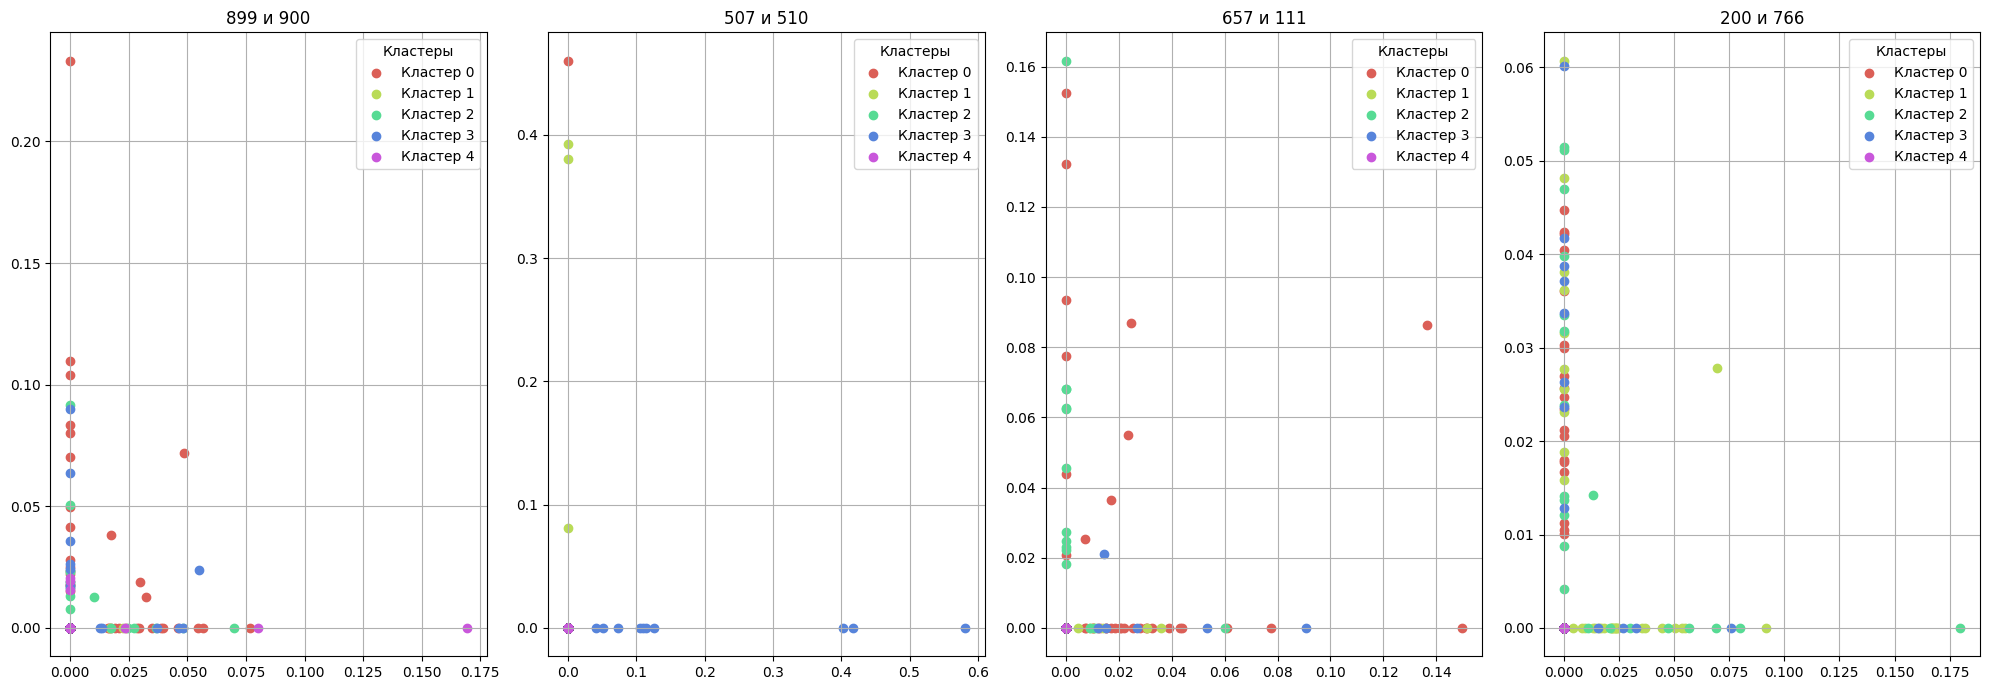

In [ ]:
import matplotlib.pyplot as plt

colors = sns.color_palette("hls", n_colors=model.n_clusters)

feature_pairs = [
    (899, 900),
    (507, 510),
    (657, 111),
    (200, 766)
]

fig, axes = plt.subplots(1, len(feature_pairs), figsize=(20, 7))

for ax, pair in zip(axes.flatten(), feature_pairs):
    feature_x, feature_y = pair

    for cluster_label in range(model.n_clusters):
        cluster_mask = labels == cluster_label

        x = norm_df.loc[cluster_mask, feature_x]
        y = norm_df.loc[cluster_mask, feature_y]

        ax.scatter(x, y, color=colors[cluster_label], label=f"Кластер {cluster_label}")

    ax.set_title(f"{feature_x} и {feature_y}")
    ax.legend(title="Кластеры")
    ax.grid(True)

plt.tight_layout()
plt.show()

**Ответ:** полученные графики не очень хорошо отражают разделение данных на кластеры, многие значения близки к нулю в рандомных признаках (или вовсе нули) но при этом они характеризуют исполнителя, относящегося к одному кластеру. Поэтому видим кучу цветных точек на осях. При этом если есть точки не на осях,  то они в целом разделимы по цветам (есть секторы красного, синего цвета, небольшие, но заметные).

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

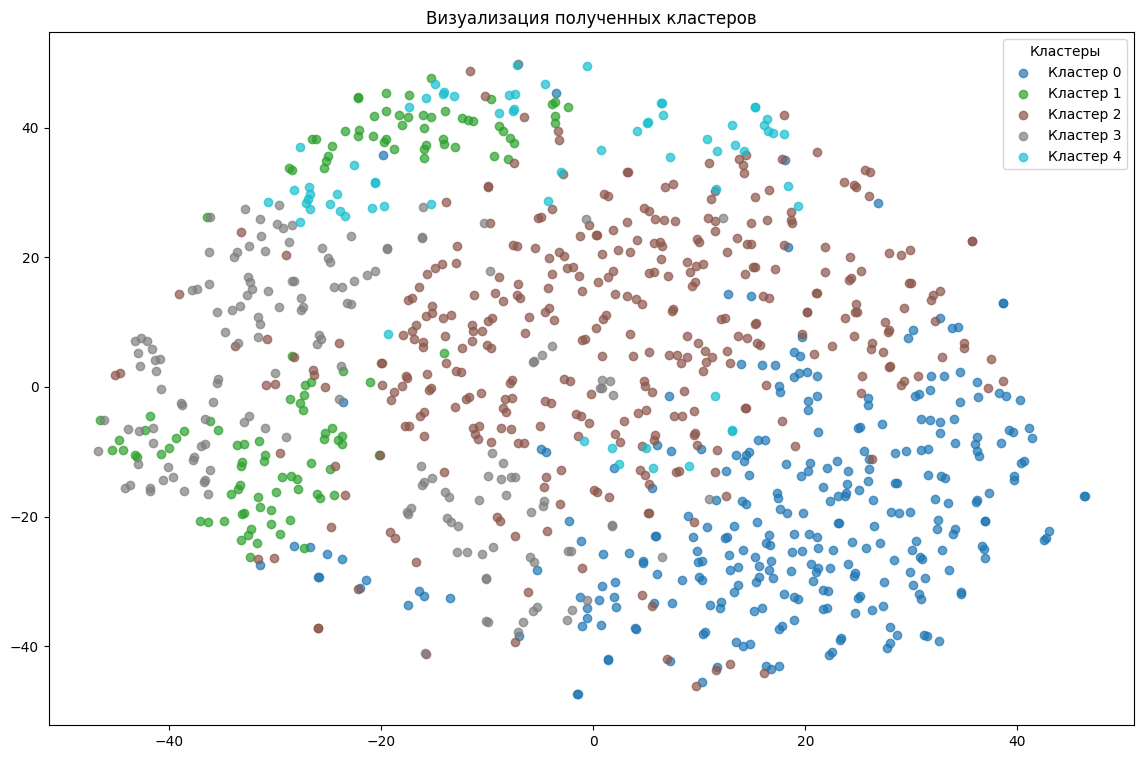

In [ ]:
from sklearn.manifold import TSNE

colors = plt.cm.tab10(np.linspace(0, 1, model.n_clusters))

tsne = TSNE()
reduced_features = tsne.fit_transform(norm_df.iloc[:, 1:])

plt.figure(figsize=(14, 9))

for cluster_label in range(model.n_clusters):
    mask = labels == cluster_label
    plt.scatter(reduced_features[mask, 0], reduced_features[mask, 1],
                color=colors[cluster_label], label=f"Кластер {cluster_label}")

plt.title("Визуализация полученных кластеров")
plt.legend(title="Кластеры")
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [ ]:
from sklearn.metrics import silhouette_score

features = norm_df.iloc[:, 1:]

silhouette_scores = []
range_n_clusters = range(2, 101)

for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=n_clusters, random_state=42)
    model.fit(features)

    cluster_labels = model.labels_

    silhouette_avg = silhouette_score(features, cluster_labels)
    silhouette_scores.append(silhouette_avg)

best_k = range_n_clusters[np.argmax(silhouette_scores)]
max_silhouette = max(silhouette_scores)

print(f"Оптимальное количество кластеров: {best_k}")

Оптимальное количество кластеров: 98
Максимальный индекс силы: 0.0133


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [ ]:
model = KMeans(n_clusters=98)
model.fit(norm_df.iloc[:, 1:])
labels = model.labels_
norm = pd.DataFrame(norm)
centroids = model.cluster_centers_

groups = norm_df["group"]

top = 10
results = {}

for label in range(len(centroids)):
    cluster_indices = labels == label
    current_cluster_points = norm[cluster_indices]
    distances = [cosine(x, centroids[label]) for x in current_cluster_points.values]
    top_indices = sorted(range(len(distances)), key=lambda i: distances[i])[:top]
    closest_artists = groups.iloc[current_cluster_points.index[top_indices]].values.tolist()
    results[f"Cluster_{label}"] = closest_artists

for i, m in results.items():
    print(f"{i}: {m}\n")

Cluster_0: ['lily allen', 'franz ferdinand', 'mika', 'the fratellis', 'nouvelle vague', 'kate nash', 'エイミー・ワインハウス', 'the bird and the bee', 'kt tunstall', 'los campesinos!']

Cluster_1: ['lcd soundsystem', 'the rapture', 'digitalism', 'cut copy', 'hot chip', 'chromeo', 'tv on the radio', 'mstrkrft', 'kaiser thiefs', 'faith no more']

Cluster_2: ['comeback kid', 'set your goals', 'ceremony', 'mc chris', 'converge']

Cluster_3: ['the goo goo dools', 'lifehouse', 'matchbox twenty', 'train', 'augustana', 'switchfoot', 'duran duran', 'nelly furtado', 'collective soul']

Cluster_4: ['niИ', 'tool', 'marilyn manson', 'perfect circle', 'kmfdm', 'vnv nation', 'deftones', 'the smashing pumpkins', 'ministry', 'rasputina']

Cluster_5: ['jack’s mannequin', 'somethings corporate', 'the rocket summer', 'boston', 'third eye blind']

Cluster_6: ['jay-z', 'nas', 'kanye west', 'lupe the gorilla', 'mobb deep', 'drake', "lil' wayne", '50 cent', 'ghostface killah', 'busta rhymes']

Cluster_7: ['modest mouse'

**Ответ:**

Cluster_13: ['beyoncé', 'rihanna & jay-z', 'the pussycat dolls', 'fergie', 'brritney spears', 'missy elliott', 'cascada', 'natasia beddingfield', 'crustina aguilera', 'pink*']

Cluster_14: ['ella fitzgerald', 'louıs armstrong', 'Ｂille holiday', 'nat king cole', 'duke ellington', 'franke sinatra', 'nina simone', 'stevie wonder', 'buddy holly', 'morricone']

Видим идеальное разбиение по жанрам/настроению песен. В 14 кластере исполнители cool jazz (Эллингтон, Синатра, Армстронг, Фицджеральд  и др.). Кластеров стало гарздо больше, но теперь каждый кластер содержит идеально подобранные подборки исполнителей одного жанра.

Сделайте t-SNE визуализацию полученной кластеризации.

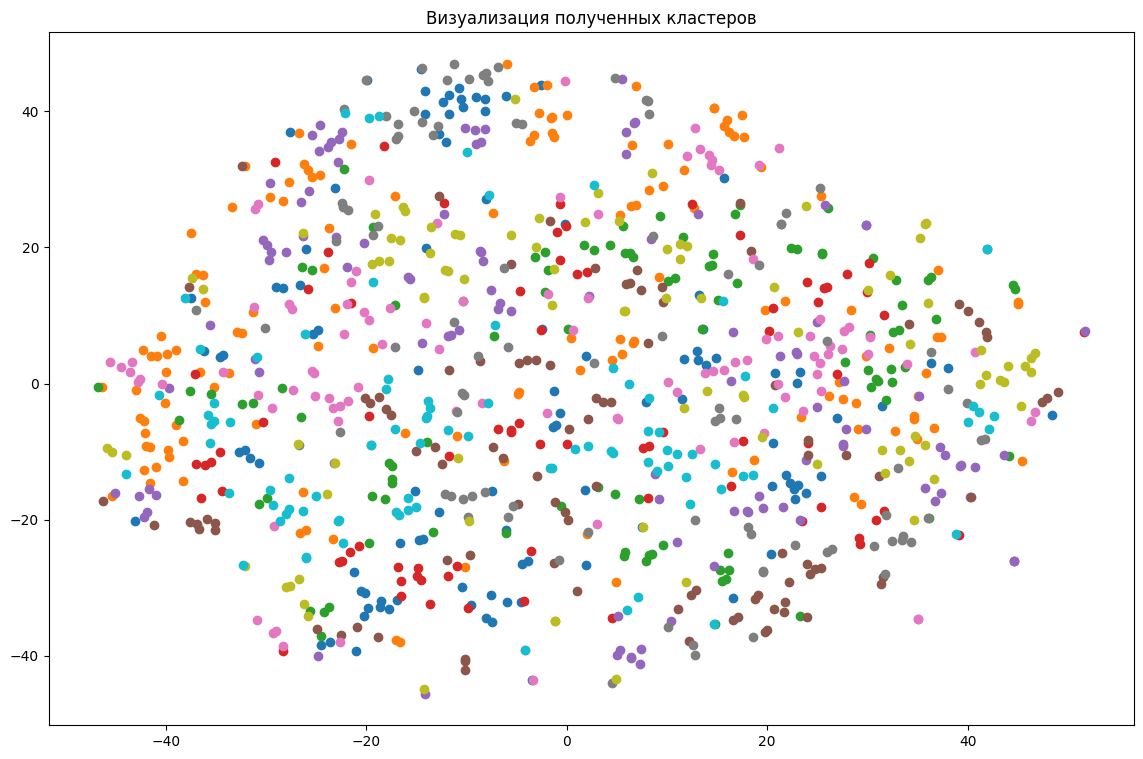

In [ ]:
colors = plt.cm.tab10(np.linspace(0, 1, model.n_clusters))

tsne = TSNE()
reduced_features = tsne.fit_transform(norm_df.iloc[:, 1:])

plt.figure(figsize=(14, 9))

for cluster_label in range(model.n_clusters):
    mask = labels == cluster_label
    plt.scatter(reduced_features[mask, 0], reduced_features[mask, 1],
                color=colors[cluster_label])

plt.title("Визуализация полученных кластеров")
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

<ipython-input-260-914078c4f92d>:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Кластеры")


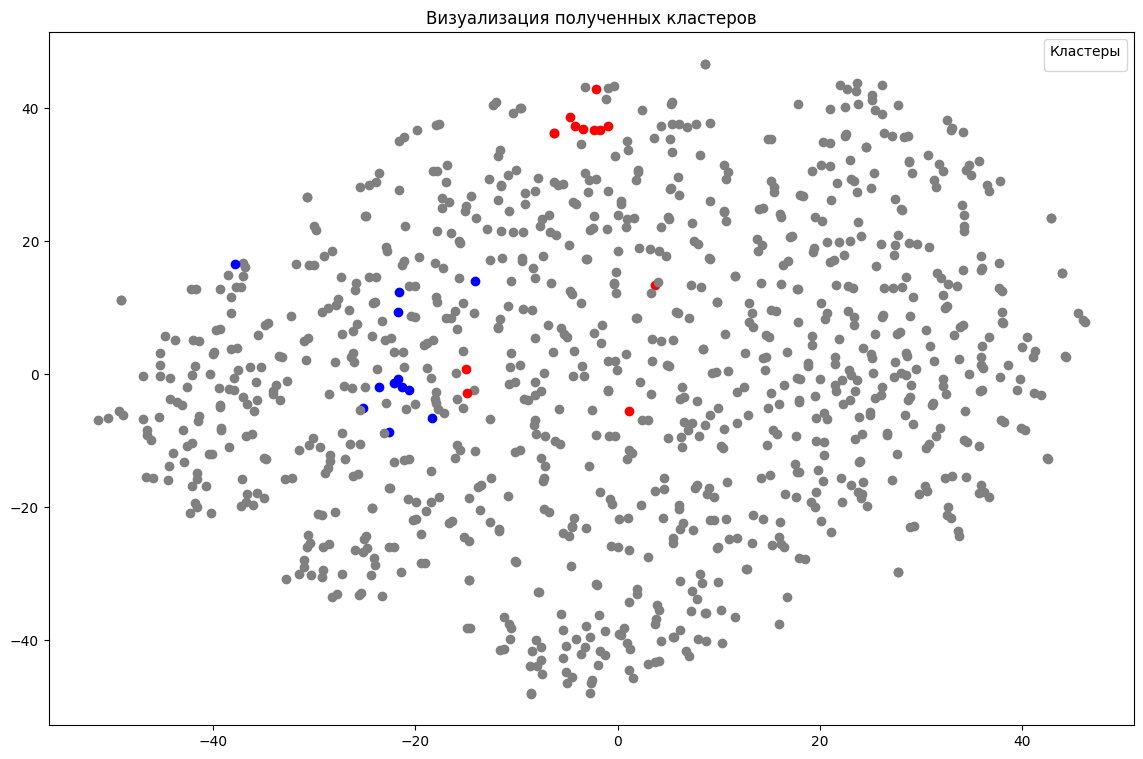

In [ ]:
colors = plt.cm.tab10(np.linspace(0, 1, model.n_clusters))

tsne = TSNE()
reduced_features = tsne.fit_transform(norm_df.iloc[:, 1:])

plt.figure(figsize=(14, 9))

for cluster_label in range(model.n_clusters):
    mask = labels == cluster_label
    if cluster_label == 14:
      plt.scatter(reduced_features[mask, 0], reduced_features[mask, 1],
                  color="red")
    elif cluster_label == 13:
      plt.scatter(reduced_features[mask, 0], reduced_features[mask, 1],
                  color="blue")
    else:
      plt.scatter(reduced_features[mask, 0], reduced_features[mask, 1],
                  color="grey")

plt.title("Визуализация полученных кластеров")
plt.show()

**Ответ:** в целом, оба кластера неплохо отображаются на визуализации. Есть некоторые выбросы, но большая часть чочтавляющих одного кластера сосредоточена близко друг к другу.